# From χ to the Wigner Function — the core WP-W chain

### How the stroboscopic train turns spin readout into a phase-space image

*Strobo-Travels-Deep · `wp-wigner-tomography` · explanatory notebook · 2026-05-17*

A readable walk-through of WP-W's central idea: an *ideal*
spin-dependent force lets you read the motional **characteristic
function** χ point-by-point from the spin, and a 2-D Fourier
transform of χ is the **Wigner function** — a full phase-space
picture of the motion, including its non-classical features.

**Where this sits in WP-W.** This is the *forward + inversion* chain
that deliverables P0/D2/D3 built and validated. The
[back-action notebook](./wpw_back_action.ipynb) is its companion and
asks the opposite question (what the measurement does *to* the
motion). This notebook is a teaching artefact; the authoritative
sources are below — it *uses* their results, it is not one.

| Authoritative source | Where |
|---|---|
| Convention-locked derivation | [`notes/analytic_chain.md`](../wp-wigner-tomography/notes/analytic_chain.md) |
| Work program | [`WORK-PROGRAM.md`](../wp-wigner-tomography/WORK-PROGRAM.md) |
| D3 reconstruction logbook | [`logbook/2026-05-15-D3-reconstruction.md`](../wp-wigner-tomography/logbook/2026-05-15-D3-reconstruction.md) |
| Committed D3 data | `wp-wigner-tomography/numerics/reconstruction_demo.h5` |

## §1 Plain-language setup

Read once; the rest of the notebook uses these words in this sense.

- **Motional state.** The quantum state of the ion's harmonic
  oscillation. We want a picture of it in *phase space* (position vs
  momentum, written as a complex amplitude α).

- **Characteristic function χ.** A *complete fingerprint* of the
  motional state: a complex-valued function of a probe displacement
  β. "Complete" means no information is lost — χ determines the
  state exactly, classical or not. You don't see the state directly
  in χ; you Fourier-transform it.

- **The ideal analysis train measures χ point-by-point.** Each
  setting of the experiment knobs places one probe point β; the
  spin readout at that setting returns the single complex number
  χ(β). Sweep the knobs → sample χ on a grid of β.

- **Wigner function W.** The phase-space picture itself: a real
  function of α that can go **negative** — and negativity is a
  signature of genuinely quantum (non-classical) motion. W is the
  2-D Fourier transform of χ. Gaussian states (vacuum, coherent,
  thermal) have W ≥ 0; Fock and cat states have W < 0 regions.

- **Why this works for *any* state.** Because χ is complete, the
  chain has no built-in "classical only" assumption. What limits the
  picture is **numerical resolution** of the grid, not formal
  validity — a theme we return to in §5–§6.

## §2 The ideal σ_x SDF and the χ readout

The probe is the Flühmann–Home **state-dependent force** (SDF) — a
displacement whose direction is set by the ion spin:

$$U_\mathrm{SDF}(\beta) = D\!\big(\sigma_x\,\tfrac{\beta}{2}\big),
\qquad D(\xi)=e^{\xi a^\dagger-\xi^* a}.$$

It splits the motion into two spin **branches** displaced by
$\pm\beta/2$, i.e. a *branch separation* β (each copy moves by
half). Prepare the spin on the equator orthogonal to σ_x
($|{+}y\rangle$). After the SDF, the spin coherence carries χ; the
two equatorial spin observables read it out **directly**:

$$\boxed{\;\chi_{\rho_m}(\beta)=\langle\sigma_y\rangle-i\,\langle\sigma_z\rangle\;}$$

**No Gaussian prefactor, no overall phase, no conjugation.**
($\langle\sigma_x\rangle$ carries no χ — σ_x is the SDF axis
itself.) This is a v0.5 correction: an earlier draft wrote
$C=e^{-|\beta|^2/2}\chi$; the $e^{-|\beta|^2/2}$ was an artefact
conflated with a different (Doppler) contrast and is **wrong** for
the σ_x-SDF / $|{+}y\rangle$ chain (`analytic_chain.md` §2). The
cell below checks the bare readout against analytic χ on the engine
itself — and shows the spurious prefactor would *not* match.

### §2 setup

In [1]:
import os, sys, json, subprocess
import numpy as np
import h5py
import matplotlib.pyplot as plt

REPO = os.path.abspath(os.path.join(os.getcwd(), ".."))
sys.path.insert(0, os.path.join(REPO, "scripts"))
sys.path.insert(0, os.path.join(REPO, "wp-wigner-tomography", "numerics"))

from stroboscopic import HilbertSpace, states
from stroboscopic.ideal_sdf import build_ideal_sdf_train

# Committed, smoke-tested helpers — reused verbatim, no duplicated formulas.
from _common import (
    chi_vacuum, chi_coherent, chi_fock, chi_cat,
    W_vacuum, W_coherent, W_fock, wigner_from_chi,
    inverse_dirichlet,
)

plt.rcParams.update({"figure.dpi": 110, "image.cmap": "RdBu_r"})
NUM = os.path.join(REPO, "wp-wigner-tomography", "numerics")
print("setup OK; D3 artefact",
      "present" if os.path.exists(os.path.join(NUM, "reconstruction_demo.h5"))
      else "MISSING")

setup OK; D3 artefact present


In [2]:
# Live readout check: one probe point, vacuum, ideal-SDF train.
# Shows  chi = <sigma_y> - i<sigma_z>  with NO prefactor, and <sigma_x> ~ 0.
OMEGA_M, BETA0, N = 1.3, 0.05, 80
beta_star = 0.5 * np.exp(1j * np.pi / 4.0)            # an arbitrary probe point
r = abs(beta_star); theta = float(np.angle(beta_star))
x = inverse_dirichlet(N, r / BETA0)
phi = (theta - (N - 1) * x / 2.0) % (2.0 * np.pi)
delta = x / (2.0 * np.pi / OMEGA_M)                    # carrier tooth k=0
NMAX = 40
hs = HilbertSpace(n_spins=1, mode_cutoffs=(NMAX,))
psi0 = np.concatenate([states.fock_state(0, NMAX), np.zeros(NMAX, complex)])
psi_eq = states.apply_mw_pi2(psi0, mw_phase_deg=0.0, nmax=NMAX)
psi_out = build_ideal_sdf_train(hs=hs, beta0=BETA0, ac_phase_rad=phi,
                                omega_m=OMEGA_M, delta=delta,
                                n_pulses=N, k_sideband=0).evolve(psi_eq)
d, u = psi_out[:NMAX], psi_out[NMAX:]
sx = 2.0 * np.real(np.vdot(d, u))
sy = -2.0 * np.imag(np.vdot(d, u))
sz = float(np.vdot(u, u).real - np.vdot(d, d).real)
chi_eng = complex(sy, -sz)                              # <sy> - i<sz>
chi_an = complex(chi_vacuum(np.array([beta_star]))[0])
print(f"probe beta* = {beta_star:.4f}   |beta*| = {r:.3f}")
print(f"chi_engine = <sy> - i<sz> = {chi_eng:.10f}")
print(f"chi_analytic (vacuum)     = {chi_an:.10f}")
print(f"|difference| = {abs(chi_eng - chi_an):.2e}   (bare readout, exact)")
print(f"<sigma_x>    = {sx:+.2e}   (carries no chi -- it IS the SDF axis)")
bad = chi_eng * np.exp(-abs(beta_star)**2 / 2.0)       # the spurious prefactor
print(f"with the WRONG e^(-|b|^2/2) prefactor: {bad:.6f}  -> "
      f"|err|={abs(bad-chi_an):.2e}  (does NOT match -- prefactor is wrong)")

probe beta* = 0.3536+0.3536j   |beta*| = 0.500
chi_engine = <sy> - i<sz> = 0.8824969026+0.0000000000j
chi_analytic (vacuum)     = 0.8824969026+0.0000000000j
|difference| = 3.13e-14   (bare readout, exact)
<sigma_x>    = +2.78e-16   (carries no chi -- it IS the SDF axis)
with the WRONG e^(-|b|^2/2) prefactor: 0.778801+0.000000j  -> |err|=1.04e-01  (does NOT match -- prefactor is wrong)


**What this showed.** The two equatorial spin observables,
combined as $\langle\sigma_y\rangle-i\langle\sigma_z\rangle$,
reproduce the analytic χ to machine precision with **nothing else
applied**. Re-introducing the old $e^{-|\beta|^2/2}$ factor *breaks*
the agreement — concrete proof the v0.5 "no prefactor" correction is
the right one. $\langle\sigma_x\rangle$ is ~0: the SDF axis carries
no χ.

## §3 Live analytic examples — χ and its Wigner transform

Three textbook states: write χ on a β grid (committed
`_common.chi_*`), Fourier-transform with the committed
`_common.wigner_from_chi`, overlay the closed-form Wigner. Because
this is *analytic* χ we may sample it as finely/widely as we like
(the real experiment cannot — that limit is §4–§5); a wide β window
is used here purely so the picture is smooth.

We plot **Re χ**, not |χ| — and that choice is itself the lesson.
The coherent state has the *same* |χ| as the vacuum (a Gaussian);
its displacement is hidden entirely in the **phase** of χ. So |χ|
alone cannot see it, but Re χ can.

**What to look for (top row, Re χ):** vacuum = a smooth positive
Gaussian; coherent = the *same Gaussian envelope but rippled* — the
oscillation is the displacement, living in the phase; Fock $|2\rangle$
= concentric **sign-alternating** rings (a Laguerre polynomial).
**Bottom row, W:** vacuum/coherent are strictly positive blobs (the
coherent one sitting at Re α ≈ 1.5); Fock $|2\rangle$ shows a clean
**negative ring** — non-classicality recovered with no special
casing, because χ is complete. The printed max|W−W_analytic| shows
the transform is exact.

vacuum         : max|W_FFT - W_analytic| = 1.44e-15   min(W) = +0.0000   (negative => non-classical)
coherent |1.5> : max|W_FFT - W_analytic| = 8.88e-16   min(W) = -0.0000   (negative => non-classical)
Fock |2>       : max|W_FFT - W_analytic| = 2.43e-12   min(W) = -0.2635   (negative => non-classical)


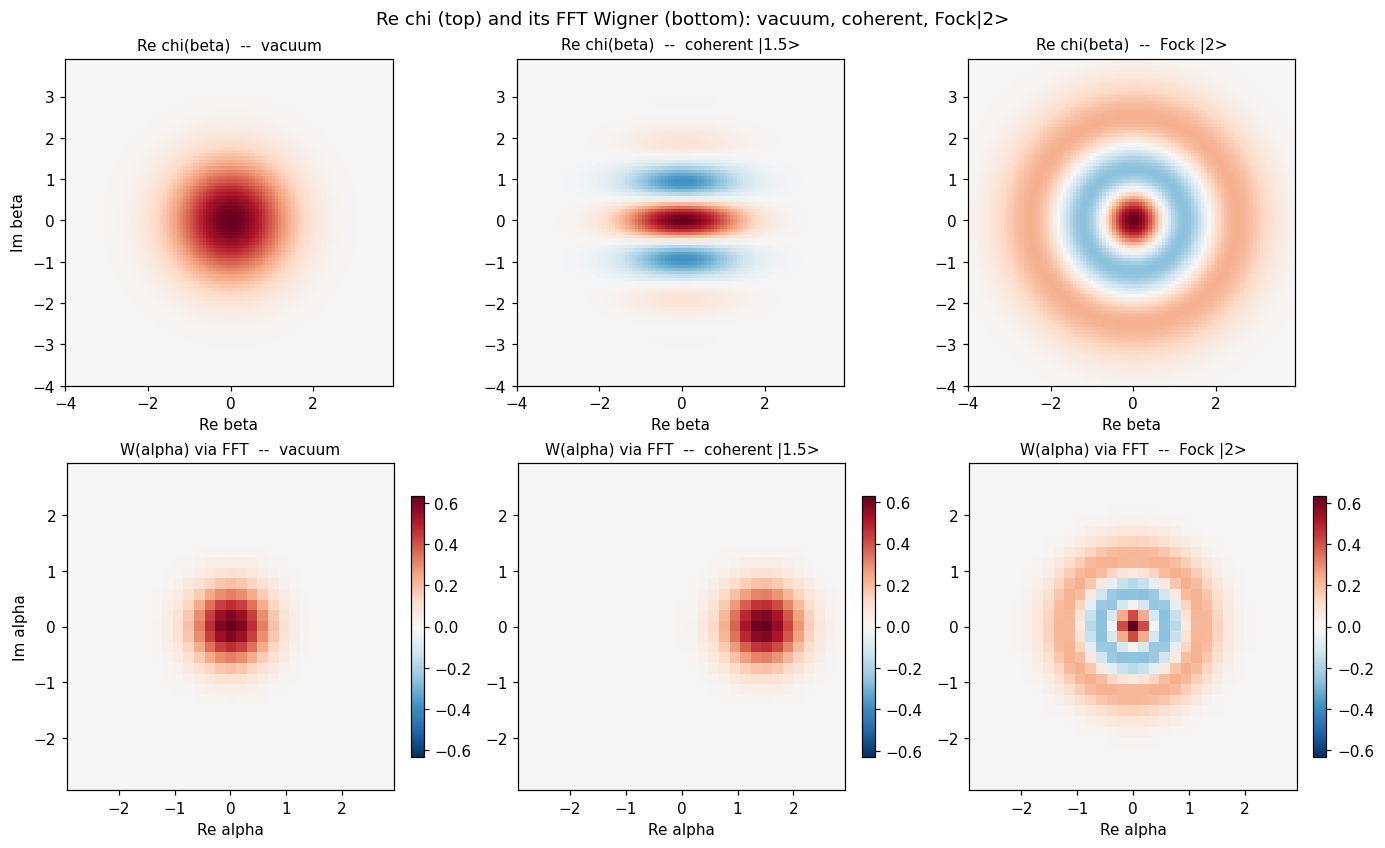

In [3]:
# Analytic chi: wide window so the FFT alpha-grid is fine (d_alpha ~ pi/(2B)).
B, DBETA = 8.0, 0.08
beta_axis = np.arange(-B, B + DBETA / 2, DBETA)
BX, BY = np.meshgrid(beta_axis, beta_axis)   # cols = Re beta, rows = Im beta
beta = BX + 1j * BY

cases = [("vacuum",         chi_vacuum(beta),              W_vacuum),
         ("coherent |1.5>",  chi_coherent(beta, 1.5 + 0j),  lambda A: W_coherent(A, 1.5+0j)),
         ("Fock |2>",        chi_fock(beta, 2),             lambda A: W_fock(A, 2))]

fig, axes = plt.subplots(2, 3, figsize=(12.5, 7.6), constrained_layout=True)
mb = np.abs(beta_axis) <= 4.0                  # chi display window
for j, (name, chi, Wfun) in enumerate(cases):
    axa, W, err = wigner_from_chi(chi, beta_axis)
    AX, AY = np.meshgrid(axa, axa)
    Wan = Wfun(AX + 1j * AY)
    m = np.abs(axa) <= 3.0                      # W physics window
    Wc, Wac = W[np.ix_(m, m)], Wan[np.ix_(m, m)]
    extW = (axa[m][0], axa[m][-1], axa[m][0], axa[m][-1])
    extC = (beta_axis[mb][0], beta_axis[mb][-1])*2
    rec = np.real(chi)[np.ix_(mb, mb)]
    a0 = axes[0, j]; vc = np.max(np.abs(rec))
    a0.imshow(rec, origin="lower", extent=extC, vmin=-vc, vmax=vc)
    a0.set_title(f"Re chi(beta)  --  {name}", fontsize=10)
    a0.set_xlabel("Re beta")
    if j == 0: a0.set_ylabel("Im beta")
    a1 = axes[1, j]; v = np.max(np.abs(Wc))
    im = a1.imshow(Wc, origin="lower", extent=extW, vmin=-v, vmax=v)
    a1.set_title(f"W(alpha) via FFT  --  {name}", fontsize=10)
    a1.set_xlabel("Re alpha")
    if j == 0: a1.set_ylabel("Im alpha")
    fig.colorbar(im, ax=a1, shrink=0.8)
    print(f"{name:15s}: max|W_FFT - W_analytic| = {np.max(np.abs(Wc-Wac)):.2e}"
          f"   min(W) = {Wc.min():+.4f}   (negative => non-classical)")
fig.suptitle("Re chi (top) and its FFT Wigner (bottom): vacuum, coherent, Fock|2>")
plt.show()

**Takeaway.** Two points. (1) **The displacement is in the
phase.** Vacuum and coherent have identical |χ|; only Re χ (the
ripples) reveals the coherent shift — which is *why* the protocol
must measure the **complex** χ ($\langle\sigma_y\rangle-i\langle\sigma_z\rangle$,
not a magnitude) and Fourier-transform it to get the real-space
picture. (2) **Completeness ⇒ non-classicality for free.** The same
FFT that returns positive vacuum/coherent blobs returns Fock
$|2\rangle$'s **negative ring** — no special casing, because χ
carries the full state. On this wide β window the FFT matches the
closed form to **machine precision** ($\sim10^{-12}$, printed above):
the transform itself is *exact*. What degrades reconstruction in the
real experiment is not the formula but the **limited** β window it
can sample — the resolution story of §4–§5.

## §4 The Fourier convention — why $\Delta\alpha=\pi/(N_g\Delta\beta)$

One subtlety trips people up. The χ ↔ W transform is *not* the
textbook FFT pair; it carries a **factor of two** in the exponent
(Cahill–Glauber):

$$W(\alpha)=\frac1{\pi^2}\!\int e^{\,2i(\alpha_y\beta_x-\alpha_x\beta_y)}\,
\chi(\beta)\,d^2\beta.$$

That factor of two changes the conjugate-grid spacing from the usual
$2\pi/(N_g\Delta\beta)$ to

$$\boxed{\;\Delta\alpha=\dfrac{\pi}{N_g\,\Delta\beta}\;}$$

**What to look for:** the printed $\Delta\alpha$ from
`wigner_from_chi` should equal $\pi/(N_g\Delta\beta)$ exactly across
grid sizes, and the imaginary part of the reconstructed W should sit
at the floating-point floor (a clean transform → real W).

In [4]:
print(f"{'N_g':>5} {'d_beta':>7} {'d_alpha (fft)':>14} "
      f"{'pi/(Ng*d_beta)':>16} {'max|Im W|':>11}")
for ng in (41, 81, 121):
    bax = (np.arange(ng) - (ng - 1) / 2.0) * DBETA
    BXn, BYn = np.meshgrid(bax, bax)
    axa, W, err = wigner_from_chi(chi_coherent(BXn + 1j*BYn, 1.5+0j), bax)
    da = float(axa[1] - axa[0]); pred = np.pi / (ng * DBETA)
    print(f"{ng:>5} {DBETA:>7.2f} {da:>14.6f} {pred:>16.6f} {err:>11.1e}")
print("\nThe textbook 2*pi/(Ng*d_beta) would give "
      f"{2*np.pi/(81*DBETA):.4f}; the correct value is "
      f"{np.pi/(81*DBETA):.4f} -- a factor of 2, from the 2i kernel.")

  N_g  d_beta  d_alpha (fft)   pi/(Ng*d_beta)   max|Im W|
   41    0.08       0.957803         0.957803     0.0e+00
   81    0.08       0.484814         0.484814     4.2e-17
  121    0.08       0.324545         0.324545     3.3e-17

The textbook 2*pi/(Ng*d_beta) would give 0.9696; the correct value is 0.4848 -- a factor of 2, from the 2i kernel.


**Takeaway.** $\Delta\alpha=\pi/(N_g\Delta\beta)$ holds exactly
at every grid size, and $\max|\mathrm{Im}\,W|\sim10^{-16}$ confirms a
clean, correctly-signed transform. Getting the factor of two wrong
would silently halve the α-axis scale — every recovered amplitude
would be off by 2×. This is why WP-W pins the convention in
`analytic_chain.md` §4 and re-checks it (gate P0).

## §5 The committed D3 reconstruction — what survives

§3 used analytic χ on a wide grid. Deliverable **D3** ran the full
inversion pipeline at WP-W's production resolution — *analytic* χ on
the v0.2 Cartesian β grid ($81^2$, $B=4$, $\Delta\beta=0.10$) →
**no taper** → zero-pad to $161^2$ → FFT — on seven states (no
engine code; this is the ideal/analytic layer). *No taper* is a
documented D3 correction: the §4 D3 spec called for a radial Hanning
window, but Hanning over the full disk over-attenuates an analytic χ
that has no disk-edge discontinuity (it dropped vacuum fidelity to
~0.86); Hanning belongs to *measured/truncated* data, not exact
analytic χ (`2026-05-15-D3-reconstruction.md`). We load that
committed artefact read-only and look at the *deciding* states.

**What to look for:** the **cat** should show the central
**interference fringes** (a quantum signature absent from a mere
classical mixture); **Fock $|2\rangle$** should show its **negative
ring**. The reconstruction is faithful where features are wider than
a pixel and degrades — never invents — where they are not.

D3 geometric-mean fidelity = 0.9013   deciding-state pass = True
  cat_1.5         fidelity = 0.9664   rho_neg = 1.268
  fock_2          fidelity = 0.9997   rho_neg = 1.008
  mixed_cat_1.5   fidelity = 0.5001


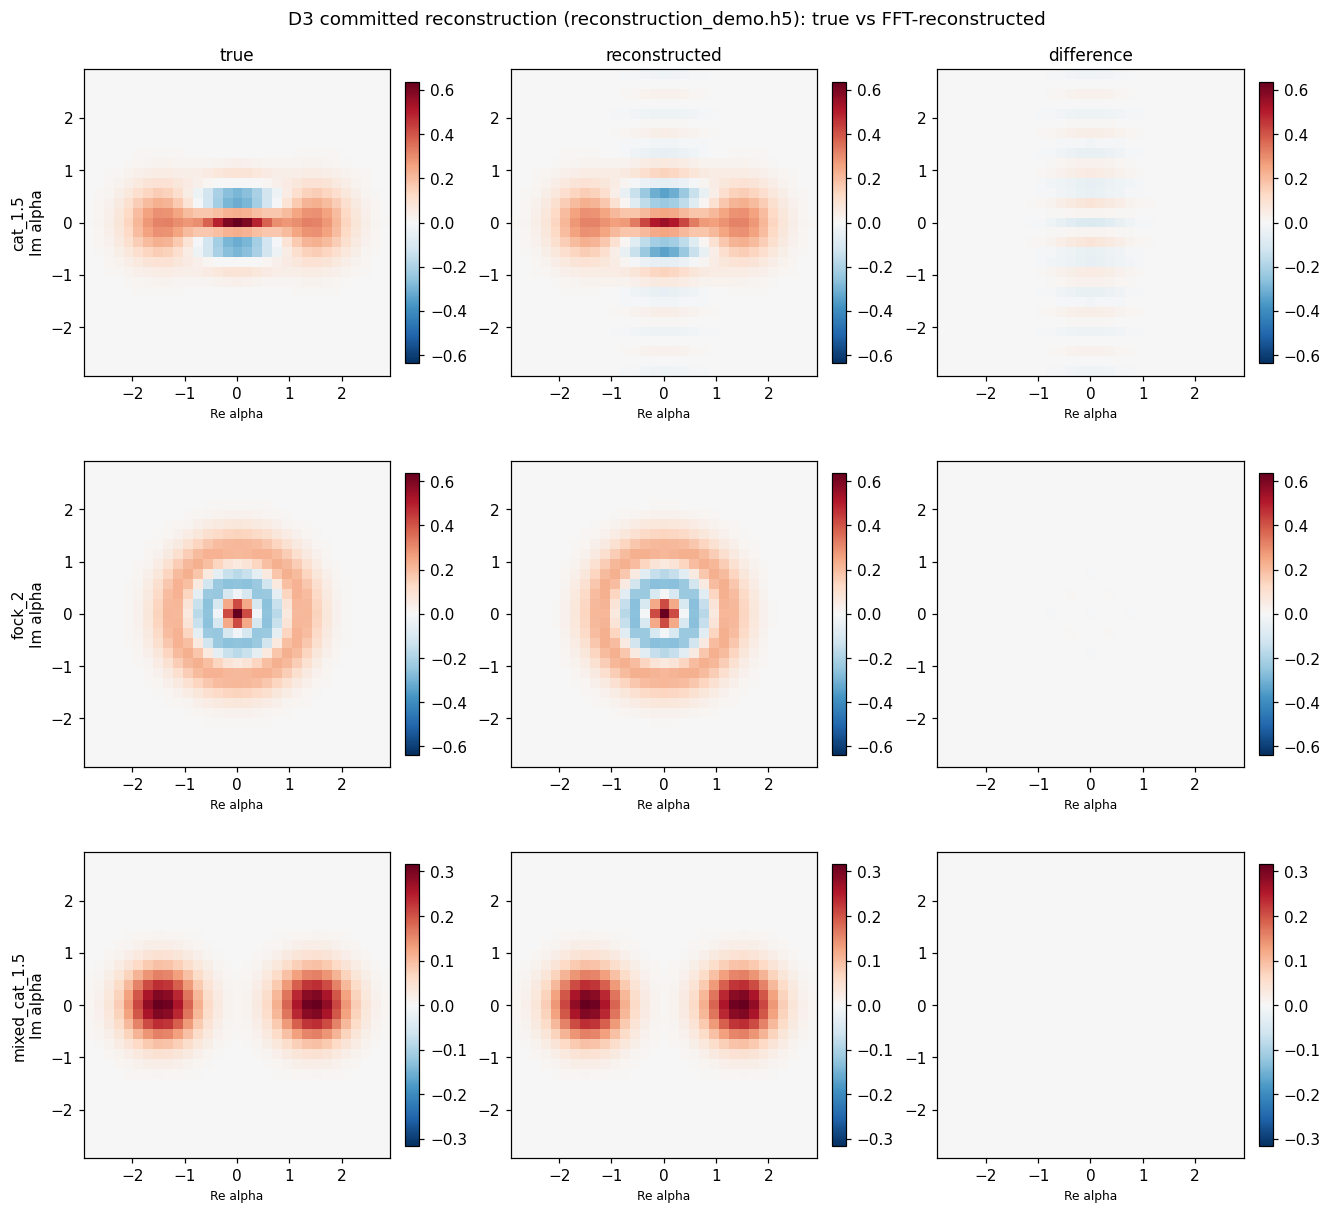

In [5]:
H5 = os.path.join(NUM, "reconstruction_demo.h5")
with h5py.File(H5, "r") as f:
    Fg = float(f.attrs["F_geomean"]); deciding = bool(f.attrs["deciding_pass"])
    show = ["cat_1.5", "fock_2", "mixed_cat_1.5"]
    panels = {}
    for g in show:
        grp = f[g]
        ax3 = grp["alpha_axis"][:]
        m = np.abs(ax3) <= 3.0
        panels[g] = dict(
            Wt=grp["W_true"][:][np.ix_(m, m)],
            Wr=grp["W_rec"][:][np.ix_(m, m)],
            ext=(ax3[m][0], ax3[m][-1], ax3[m][0], ax3[m][-1]),
            F=float(grp.attrs["metric_fidelity"]),
            rn=float(grp.attrs.get("metric_rho_neg", np.nan)))
print(f"D3 geometric-mean fidelity = {Fg:.4f}   deciding-state pass = {deciding}")
for g in show:
    p = panels[g]
    rn = "" if np.isnan(p["rn"]) else f"   rho_neg = {p['rn']:.3f}"
    print(f"  {g:14s}  fidelity = {p['F']:.4f}{rn}")

fig, axes = plt.subplots(3, 3, figsize=(12, 11), constrained_layout=True)
for ri, g in enumerate(show):
    p = panels[g]
    v = max(np.max(np.abs(p["Wt"])), np.max(np.abs(p["Wr"])))
    for ci, (dat, t) in enumerate([(p["Wt"], "true"), (p["Wr"], "reconstructed"),
                                   (p["Wr"] - p["Wt"], "difference")]):
        a = axes[ri, ci]
        im = a.imshow(dat, origin="lower", extent=p["ext"], vmin=-v, vmax=v)
        if ri == 0: a.set_title(t, fontsize=11)
        if ci == 0: a.set_ylabel(g + "\nIm alpha", fontsize=10)
        a.set_xlabel("Re alpha", fontsize=8); fig.colorbar(im, ax=a, shrink=0.8)
fig.suptitle("D3 committed reconstruction (reconstruction_demo.h5): "
             "true vs FFT-reconstructed", fontsize=12)
plt.show()

**Reading the grid.**

- **cat $|\alpha|{=}1.5$** — the central **fringes are recovered**
  (fidelity ≈ 0.97). They are *coarsely* sampled (fringe period
  ≈ 1.05 vs $\Delta\alpha\approx0.20$ on the padded grid), so the
  reconstruction slightly **overshoots** the negativity
  ($\rho_\mathrm{neg}\approx1.27$, i.e. 127 % of the true dip) — a
  documented D3 finding: report negativity one-sided, not as a
  symmetric window.
- **Fock $|2\rangle$** — fidelity ≈ 0.9997; the negative ring is
  reproduced almost exactly. This is the tightest of the "easy"
  features and it passes cleanly.
- **mixed cat** — the *classical* control: an incoherent two-hump
  Gaussian. The reconstruction shows **no fringes** — confirming the
  pipeline does not *invent* quantum structure. Cat-vs-mixed-cat
  together is WP-W's quantum/classical discriminator.

## §6 Takeaways

1. **One complete object.** χ determines the state fully; W is its
   factor-of-two Fourier transform. The chain therefore works for
   **non-Gaussian** states with no special casing — Fock negativity
   and cat fringes come out of the same FFT as the vacuum Gaussian.

2. **Resolution, not validity, is the limit.** Where a feature is
   wider than a pixel ($\Delta\alpha=\pi/(N_g\Delta\beta)$) it is
   faithful; where it is not (tight cat fringes) it degrades or
   slightly overshoots — but it does **not** fabricate structure
   (the mixed-cat control proves this).

3. **This is the ideal/analytic layer.** D3 uses the *ideal* σ_x
   SDF. How the *real* monochromatic Raman engine departs from this
   is a separate, structural question — P1/D4 and the
   [back-action notebook](./wpw_back_action.ipynb); a dedicated
   `wpw_native_bridge` notebook is the planned next step.

## §7 Provenance

In [6]:
def _git_short():
    try:
        return subprocess.check_output(
            ["git", "-C", REPO, "rev-parse", "--short", "HEAD"],
            text=True).strip()
    except Exception as e:
        return f"(unavailable: {e})"

man_path = os.path.join(NUM, "reconstruction_demo.manifest.json")
man = json.load(open(man_path))
print("notebook                       : notebooks/wpw_chi_to_wigner.ipynb")
print("code/artefact commit @ exec    :", _git_short(),
      " (repo state the notebook was run against; the notebook's own"
      " commit is the next one)")
print("input artefact                 : wp-wigner-tomography/numerics/reconstruction_demo.h5")
print("  manifest                     : .../reconstruction_demo.manifest.json")
print("  schema / wp_id               :", man["schema_version"], "/", man["wp_id"])
print("  artefact sha256              :", man["artifact"]["sha256"])
print("  provenance_hash              :", man["provenance_hash"])
print("helpers                        : wp-wigner-tomography/numerics/_common.py "
      "(smoke-tested; see test_back_action_helpers.py)")
print("\nThis notebook is a synthesis artefact; the artefact + manifest "
      "above are the provenance-bound source of the §5 numbers.")

notebook                       : notebooks/wpw_chi_to_wigner.ipynb
code/artefact commit @ exec    : c5f7f9d  (repo state the notebook was run against; the notebook's own commit is the next one)
input artefact                 : wp-wigner-tomography/numerics/reconstruction_demo.h5
  manifest                     : .../reconstruction_demo.manifest.json
  schema / wp_id               : 1.0 / wigner-tomography
  artefact sha256              : 8455da7bf112b23b7126c9f9b9c5831425ebf6b40665dceddbc4974ba0a3336e
  provenance_hash              : 42f9d3f5e350ac0c63cf9a4afa3e2c2cb4c04d8e912f9ca1bb92aabea2a77a9b
helpers                        : wp-wigner-tomography/numerics/_common.py (smoke-tested; see test_back_action_helpers.py)

This notebook is a synthesis artefact; the artefact + manifest above are the provenance-bound source of the §5 numbers.


## §8 References

Verified subset (full bibliography + per-paper extractions:
[`WORK-PROGRAM.md`](../wp-wigner-tomography/WORK-PROGRAM.md)
§References — not duplicated here).

- **[CG69]** Cahill & Glauber, Phys. Rev. **177**, 1882 (1969).
  [doi:10.1103/PhysRev.177.1882](https://doi.org/10.1103/PhysRev.177.1882)
  — the phase-space formalism; the χ↔W Fourier pair and the
  factor-of-two convention of §4.
- **[FH20]** Flühmann & Home, Phys. Rev. Lett. **125**, 043602
  (2020). [doi:10.1103/PhysRevLett.125.043602](https://doi.org/10.1103/PhysRevLett.125.043602)
  — the σ_x SDF + direct χ readout of §2 (the WP-W chain inherits
  this; the stroboscopic-comb adaptation is WP-W's contribution).
- **[LD97]** Lutterbach & Davidovich, Phys. Rev. Lett. **78**, 2547
  (1997). [doi:10.1103/PhysRevLett.78.2547](https://doi.org/10.1103/PhysRevLett.78.2547)
  — direct phase-space measurement lineage (parity route; the
  back-action notebook's Wigner estimator).
- **[Hasse24]** Hasse, Palani, Thomm, Warring, Schaetz, Phys. Rev. A
  **109**, 053105 (2024).
  [doi:10.1103/PhysRevA.109.053105](https://doi.org/10.1103/PhysRevA.109.053105)
  — the stroboscopic protocol WP-W reinterprets.
- **[LBMW03]** Leibfried, Blatt, Monroe, Wineland, Rev. Mod. Phys.
  **75**, 281 (2003).
  [doi:10.1103/RevModPhys.75.281](https://doi.org/10.1103/RevModPhys.75.281)
  — trapped-ion Lamb–Dicke / spin–motion reference.